In [49]:
import matplotlib.pyplot as plt

# Step 1 | $ (m+1) $-sequence 생성

## 1.1 24개 Clifford 정의

In [50]:
import pennylane as qml
import numpy as np

# ==================================================
# 1. Clifford 24개 정의 (corrected)
# ==================================================

def get_single_qubit_cliffords():
    I = np.eye(2, dtype=complex)
    H = (1/np.sqrt(2))*np.array([[1,1],[1,-1]], dtype=complex)
    S = np.array([[1,0],[0,1j]], dtype=complex)

    # ------------------------------
    # global phase canonicalization
    # ------------------------------
    def canonicalize(U):
        # 첫 번째 non-zero entry 기준으로 phase 제거
        for i in range(U.shape[0]):
            for j in range(U.shape[1]):
                if not np.isclose(U[i, j], 0):
                    phase = U[i, j] / np.abs(U[i, j])
                    return U / phase
        return U

    # ------------------------------
    # closure 생성
    # ------------------------------
    queue = [I]
    unique = []

    while queue:
        U = queue.pop()
        Uc = canonicalize(U)

        # 이미 있으면 skip
        if any(np.allclose(Uc, V) for V in unique):
            continue

        unique.append(Uc)

        # generator 확장 (H, S)
        for G in [H, S]:
            queue.append(G @ U)
            queue.append(U @ G)

    return unique


# ==================================================
# 실행 및 확인
# ==================================================

cliffords = get_single_qubit_cliffords()
print("Number of Cliffords:", len(cliffords))

# sanity check 1: 반드시 24개
assert len(cliffords) == 24

# sanity check 2: unitary 확인
for U in cliffords:
    assert np.allclose(U.conj().T @ U, np.eye(2))

print("All checks passed.")

Number of Cliffords: 24
All checks passed.


In [51]:
len(cliffords)

24

In [52]:
cliffords[:10]

[array([[1.+0.j, 0.+0.j],
        [0.+0.j, 1.+0.j]]),
 array([[1.+0.j, 0.+0.j],
        [0.+0.j, 0.+1.j]]),
 array([[ 1.+0.j,  0.+0.j],
        [ 0.+0.j, -1.+0.j]]),
 array([[1.+0.j, 0.+0.j],
        [0.+0.j, 0.-1.j]]),
 array([[0.70710678+0.j        , 0.70710678+0.j        ],
        [0.        -0.70710678j, 0.        +0.70710678j]]),
 array([[ 0.70710678+0.j        ,  0.        +0.70710678j],
        [ 0.        -0.70710678j, -0.70710678+0.j        ]]),
 array([[ 0.70710678+0.j        , -0.70710678+0.j        ],
        [ 0.        -0.70710678j,  0.        -0.70710678j]]),
 array([[0.70710678+0.j        , 0.        -0.70710678j],
        [0.        -0.70710678j, 0.70710678+0.j        ]]),
 array([[0.70710678+0.j        , 0.        -0.70710678j],
        [0.70710678+0.j        , 0.        +0.70710678j]]),
 array([[ 0.70710678+0.j,  0.70710678+0.j],
        [ 0.70710678+0.j, -0.70710678+0.j]])]

## 1.2 랜덤 sequence 생성

In [53]:
def sample_clifford_sequence(m, cliffords):
    indices = np.random.choice(len(cliffords), size=m)
    return [cliffords[i] for i in indices], indices

In [54]:
random_clifford_sequence, random_indices = sample_clifford_sequence(5, cliffords)
print("Random Clifford sequence (matrices):")
for i, C in enumerate(random_clifford_sequence):
    print(f"C_{i}:\n{C}\n")
print("Random Clifford sequence (indices):", random_indices)

Random Clifford sequence (matrices):
C_0:
[[ 0.70710678+0.j         -0.70710678+0.j        ]
 [ 0.        +0.70710678j  0.        +0.70710678j]]

C_1:
[[ 0.70710678+0.j -0.70710678+0.j]
 [ 0.70710678+0.j  0.70710678+0.j]]

C_2:
[[0.70710678+0.j         0.70710678+0.j        ]
 [0.        +0.70710678j 0.        -0.70710678j]]

C_3:
[[ 0.70710678+0.j -0.70710678+0.j]
 [-0.70710678+0.j -0.70710678+0.j]]

C_4:
[[ 0.00000000e+00+2.23711432e-17j  1.00000000e+00+0.00000000e+00j]
 [ 0.00000000e+00-1.00000000e+00j -2.23711432e-17-0.00000000e+00j]]

Random Clifford sequence (indices): [12 11 14 17 21]


## 1.3 Inverse gate 계산

In [55]:
def compute_inverse(sequence):
    U = np.eye(2)
    for C in sequence:
        U = C @ U
    return U.conj().T

In [56]:
compute_inverse(random_clifford_sequence)

array([[-1.00000000e+00-6.11714288e-34j, -1.01465364e-17+6.22328532e-19j],
       [ 6.22328532e-19-1.01465364e-17j, -6.11714288e-34-1.00000000e+00j]])

## 1.4 Step 1 전체 테스트

In [57]:
def test_identity(m=10):
    seq, _ = sample_clifford_sequence(m, cliffords)
    U_inv = compute_inverse(seq)
    U = np.eye(2)

    for C in seq:
        U = C @ U

    print("U (product of sequence):\n", U)
    print("U_inv (inverse):\n", U_inv)

    U_total = U @ U_inv

    print("U_total (should be identity):\n", U_total)

    return np.allclose(U_total, np.eye(2))

test_identity()

U (product of sequence):
 [[-7.07106781e-01+4.30988407e-34j  4.30988407e-34-7.07106781e-01j]
 [ 1.09170849e-35-7.07106781e-01j -7.07106781e-01+1.09170849e-35j]]
U_inv (inverse):
 [[-7.07106781e-01-4.30988407e-34j  1.09170849e-35+7.07106781e-01j]
 [ 4.30988407e-34+7.07106781e-01j -7.07106781e-01-1.09170849e-35j]]
U_total (should be identity):
 [[ 1.00000000e+00+0.j -6.24948741e-34+0.j]
 [-6.24948741e-34+0.j  1.00000000e+00+0.j]]


True

# Step 2 | 각 Sequence에 대한 measure

In [58]:
dev = qml.device("default.mixed", wires=1)

In [59]:
@qml.qnode(dev)
def rb_single_sequence(seq, U_inv):
    # 초기 상태 |0⟩ (기본값)

    # forward sequence
    for C in seq:
        qml.QubitUnitary(C, wires=0)

    # inverse 적용
    qml.QubitUnitary(U_inv, wires=0)

    # measurement
    return qml.probs(wires=0)

In [60]:
def survival_probability(seq):
    U_inv = compute_inverse(seq)
    probs = rb_single_sequence(seq, U_inv)
    return probs[0]   # P(|0>)

In [61]:
seq, _ = sample_clifford_sequence(10, cliffords)

p = survival_probability(seq)

print("Survival probability:", p)

Survival probability: 0.9999999999999958


In [62]:
for m in [1, 5, 10, 20, 30]:
    seq, _ = sample_clifford_sequence(m, cliffords)
    print(m, survival_probability(seq))

1 1.0
5 0.9999999999999984
10 0.9999999999999949
20 0.9999999999999925
30 0.9999999999999911


# Step 2 (Noise)

## 2-1. Noise 함수 추가

In [63]:
def apply_noise(gate_idx, step_idx, p=0.01):
    """
    Λ_{i_j,j} 구현

    현재:
        gate-independent depolarizing noise

    구조:
        이후 gate-dependent / time-dependent 확장 가능
    """
    qml.DepolarizingChannel(p, wires=0)

In [64]:
def apply_noise(gate_idx, step_idx, p=0.01):

    # gate마다 다른 noise
    p_using = p * (1 + 0.5 * (gate_idx % 3))

    qml.DepolarizingChannel(p_using, wires=0)

## 2-2. Noisy QNode 추가

In [65]:
@qml.qnode(dev)
def rb_single_sequence_noisy(seq, seq_indices, p_noise=0.01):

    # 초기 상태 |0>

    # -------------------------
    # forward: C → Λ
    # -------------------------
    for j, (C, idx) in enumerate(zip(seq, seq_indices)):
        qml.QubitUnitary(C, wires=0)

        # Λ_{i_j,j}
        apply_noise(idx, j, p=p_noise)

    # -------------------------
    # inverse gate
    # -------------------------
    U_inv = compute_inverse(seq)
    qml.QubitUnitary(U_inv, wires=0)

    # -------------------------
    # 마지막 noise Λ_{m+1}
    # -------------------------
    apply_noise(-1, len(seq), p=p_noise)

    # measurement
    return qml.probs(wires=0)

## 2-3. survival probability (noisy)

In [66]:
def survival_probability_noisy(seq, seq_indices, p_noise=0.01):
    probs = rb_single_sequence_noisy(seq, seq_indices, p_noise)
    return probs[0]

# Step 3 | Sequence들의 평균 fidelity 계산

In [67]:
def average_sequence_fidelity(m, cliffords, K=100, p_noise=0.01):
    """
    논문:
        F_seq(m) = Tr[E S_m(rho)]
        S_m = average over sequences

    구현:
        Monte Carlo로 sequence 평균
    """

    probs = []

    for _ in range(K):
        # Step 1: sequence 생성
        seq, indices = sample_clifford_sequence(m, cliffords)

        # Step 2: survival probability 계산
        if p_noise > 0:
            p = survival_probability_noisy(seq, indices, p_noise=p_noise)
        else:
            p = survival_probability(seq)

        probs.append(p)

    # Step 3: 평균
    return np.mean(probs)

In [68]:
# 테스트

for m in [1, 5, 10, 20]:
    Fm = average_sequence_fidelity(m, cliffords, K=50)
    print(f"m={m}, F_seq={Fm}")

m=1, F_seq=0.9763493333333727
m=5, F_seq=0.9406286928097802
m=10, F_seq=0.896983806406879
m=20, F_seq=0.8249170950131


# Step 4 | 함수로 fitting

## 4-1. fitting 함수 정의

In [69]:
from scipy.optimize import curve_fit
import numpy as np


def rb_model(m, A, p, B):
    return A * (p ** m) + B


def fit_rb_decay(m_list, F_list):
    """
    논문 Step 4:
        F(m) = A p^m + B

    입력:
        m_list : sequence lengths
        F_list : average fidelities

    출력:
        A, p, B
    """

    m_arr = np.array(m_list, dtype=float)
    F_arr = np.array(F_list, dtype=float)

    # --------------------------
    # 초기값 설정 (중요)
    # --------------------------
    A0 = 0.5
    p0 = 0.99
    B0 = 0.5

    popt, pcov = curve_fit(
        rb_model,
        m_arr,
        F_arr,
        p0=[A0, p0, B0],
        bounds=([0, 0, 0], [1, 1, 1])
    )

    A, p, B = popt

    return A, p, B

## 4-2. error rate 계산하는 함수
$$ r = 1- p -{ 1 - p \over d} $$
- 1-qubit $\to d = 2$ 

In [70]:
def compute_error_rate(p, d=2):
    return 1 - p - (1 - p) / d

## 4-3. 테스트 코드

In [71]:
# fake exponential data (테스트용)
m_list = np.arange(1, 20)
true_p = 0.95

F_list = 0.5 * (true_p ** m_list) + 0.5

A, p, B = fit_rb_decay(m_list, F_list)

print("Fitted A:", A)
print("Fitted p:", p)
print("Fitted B:", B)

r = compute_error_rate(p)
print("Estimated error rate r:", r)

Fitted A: 0.5000000003706915
Fitted p: 0.9500000000950701
Fitted B: 0.49999999957151336
Estimated error rate r: 0.024999999952464935


# Step 5 | $ m $에 따른 $F(m)$ decay curve 확인

## 5-1. 데이터 생성

In [72]:
import numpy as np

ms = np.arange(1, 50)

F_list = []
for m in ms:
    Fm = average_sequence_fidelity(
        m,
        cliffords,
        K=100,
        p_noise=0.01   # ← 여기로 control
    )
    F_list.append(Fm)

In [73]:
for m, Fm in zip(ms, F_list):
    print(f"m={m}, F={Fm}")

m=1, F=0.9769982222222616
m=2, F=0.967615288888948
m=3, F=0.9580488829432886
m=4, F=0.9488208081449543
m=5, F=0.9399907979479226
m=6, F=0.9318782420249465
m=7, F=0.9224782258700336
m=8, F=0.9142345551479891
m=9, F=0.9050887327608669
m=10, F=0.8967258238099329
m=11, F=0.8895655703327379
m=12, F=0.8813598920381196
m=13, F=0.8737492765770818
m=14, F=0.866253690324361
m=15, F=0.8583147875071486
m=16, F=0.8527899281515665
m=17, F=0.8453553893952414
m=18, F=0.8387958652812838
m=19, F=0.8297444103674516
m=20, F=0.8246165233614907
m=21, F=0.8182353361845296
m=22, F=0.8109759396943989
m=23, F=0.8067996557592749
m=24, F=0.7999312316977243
m=25, F=0.7930302055345914
m=26, F=0.7871108691395583
m=27, F=0.782275762460148
m=28, F=0.7767912117086593
m=29, F=0.771115202290869
m=30, F=0.7650686163946117
m=31, F=0.7599504230537606
m=32, F=0.7547562753843287
m=33, F=0.7494054047529092
m=34, F=0.7431667193640156
m=35, F=0.740325280349984
m=36, F=0.7334612689167811
m=37, F=0.7293411861561228
m=38, F=0.72616

## 5-2. 그래프

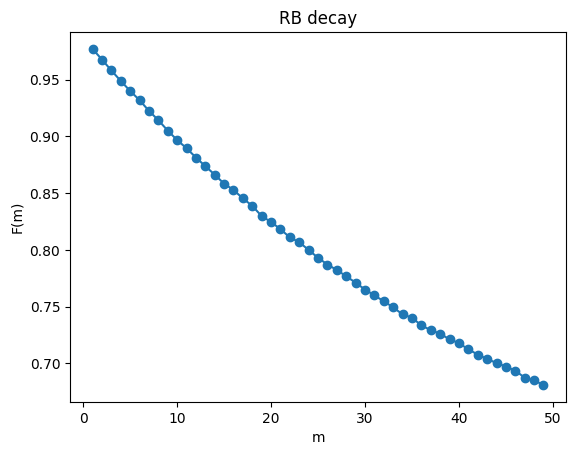

In [74]:
plt.plot(ms, F_list, 'o-')
plt.xlabel("m")
plt.ylabel("F(m)")
plt.title("RB decay")
plt.show()

## 5-3. Step 4 (fitting) 수행

In [75]:
A, p, B = fit_rb_decay(ms, F_list)

print("Fitted A:", A)
print("Fitted p:", p)
print("Fitted B:", B)

r = compute_error_rate(p)
print("Estimated error rate r:", r)

Fitted A: 0.48137735322598785
Fitted p: 0.9796235174331075
Fitted B: 0.5056142350531394
Estimated error rate r: 0.010188241283446253
